https://github.com/tesseract-ocr/tessdata

https://github.com/tesseract-ocr/tessdata/blob/main/eng.traineddata

## Aula 1

In [1]:
import cv2
import pytesseract

In [2]:
print(f"Versão cv2: {cv2.__version__}")
print(f"Versão pytesseract: {pytesseract.__version__}")

Versão cv2: 4.11.0
Versão pytesseract: 0.3.13


In [3]:
image_book = cv2.imread("images/trecho_livro.png")

In [4]:
# cv2.imshow("Trecho livro", image_book)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

Outras opções de 'show'

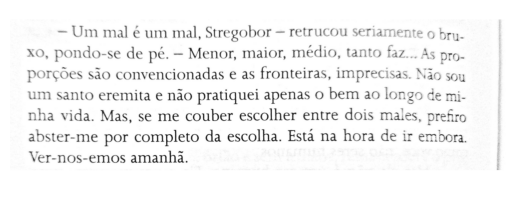

In [5]:
import matplotlib.pyplot as plt

image_book_RGB = cv2.cvtColor(image_book, cv2.COLOR_BGR2RGB)
plt.imshow(image_book_RGB)
plt.axis("off")
plt.show()

Continuando com o projeto

In [6]:
text_book = pytesseract.image_to_string(image_book_RGB)
print(text_book)

— Um mal é um mal, Stregobor — retrucou seriamente 0 bry.
xo, pondo-se de pé. — Menor, maior, médio, tanto faz... A
porgdes sao convencionadas e as fronteiras, imprecisas.
um santo eremita e nao pratiquei apenas 0 bem ao longo de mi-
nha vida. Mas, se me couber escolher entre dois males, prefiro

abster-me por completo da escolha. Esta na hora de ir embora.
Ver-nos-emos amanha.

S Dro-

40 SOU




In [7]:
!tesseract --help-psm

Page segmentation modes (PSM):
  0|osd_only                Orientation and script detection (OSD) only.
  1|auto_osd                Automatic page segmentation with OSD.
  2|auto_only               Automatic page segmentation, but no OSD, or OCR. (not implemented)
  3|auto                    Fully automatic page segmentation, but no OSD. (Default)
  4|single_column           Assume a single column of text of variable sizes.
  5|single_block_vert_text  Assume a single uniform block of vertically aligned text.
  6|single_block            Assume a single uniform block of text.
  7|single_line             Treat the image as a single text line.
  8|single_word             Treat the image as a single word.
  9|circle_word             Treat the image as a single word in a circle.
 10|single_char             Treat the image as a single character.
 11|sparse_text             Sparse text. Find as much text as possible in no particular order.
 12|sparse_text_osd         Sparse text with OSD.
 13|

In [8]:
config_tesseract = '--tessdata-dir ../tessdata --psm 6'

In [9]:
text_book_config = pytesseract.image_to_string(image_book_RGB, lang = 'por', config = config_tesseract)
print(text_book_config)

— Um mal é um mal, Stregobor — retrucou seriamente o bry-
xo, pondo-se de pé. — Menor, maior, médio, tanto faz... As pro-
porções são convencionadas e as fronteiras, imprecisas. Não sou
um santo eremita e não pratiquei apenas o bem ao longo de mi-
nha vida. Mas, se me couber escolher entre dois males, prefiro
abster-me por completo da escolha. Está na hora de ir embora. |
Ver-nos-emos amanhã. |



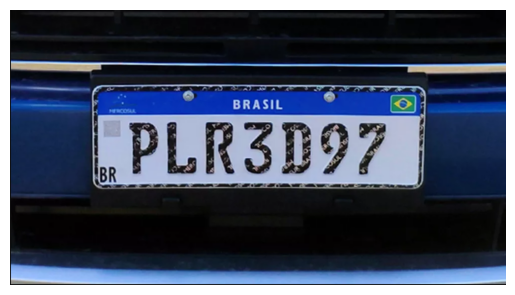

In [10]:
image_car_1 = cv2.imread("images/placa_carro1.png")
image_car_1_RGB = cv2.cvtColor(image_car_1, cv2.COLOR_BGR2RGB)
plt.imshow(image_car_1_RGB)
plt.axis("off")
plt.show()

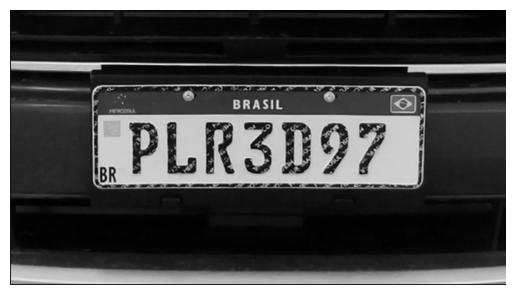

In [11]:
image_car_1_GRAY = cv2.cvtColor(image_car_1, cv2.COLOR_BGR2GRAY)
plt.imshow(image_car_1_GRAY, cmap="gray")
plt.axis("off")
plt.show()

In [12]:
config_tesseract = '--tessdata-dir ../tessdata --psm 6'
text_car = pytesseract.image_to_string(image_car_1_GRAY, lang='por', config=config_tesseract)
print(text_car)

. PLRSD97 |
o



## Aula 02

Limiarização simples

- Escala de cinza para branco/preto

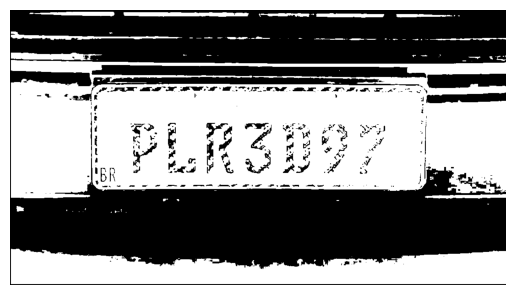

In [13]:
threshold_fix = 25
value, threshold_simple = cv2.threshold(image_car_1_GRAY, threshold_fix, 255, cv2.THRESH_BINARY)
plt.imshow(threshold_simple, cmap="gray")
plt.axis("off")
plt.show()

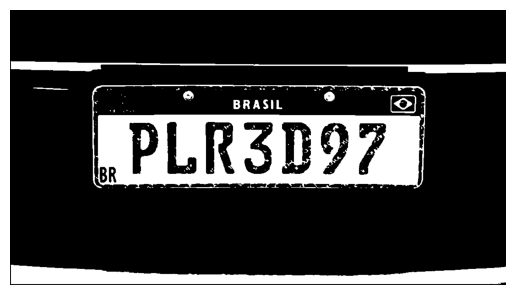

In [14]:
threshold_fix = 127
value, threshold_simple = cv2.threshold(image_car_1_GRAY, threshold_fix, 255, cv2.THRESH_BINARY)
plt.imshow(threshold_simple, cmap="gray")
plt.axis("off")
plt.show()

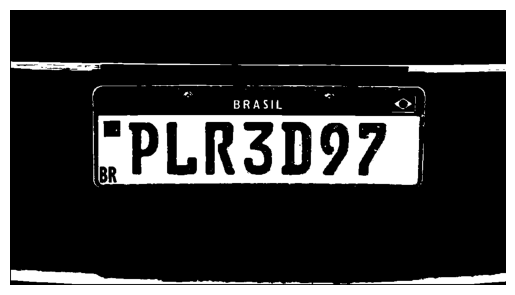

In [15]:
threshold_fix = 170
value, threshold_simple = cv2.threshold(image_car_1_GRAY, threshold_fix, 255, cv2.THRESH_BINARY)
plt.imshow(threshold_simple, cmap="gray")
plt.axis("off")
plt.show()

Limiarização adaptativa

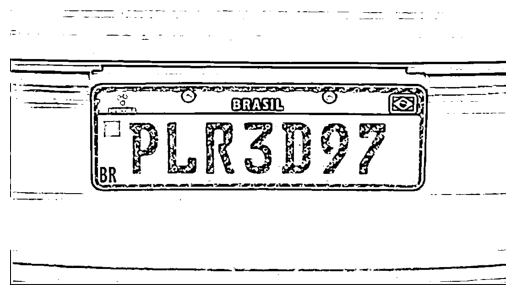

In [16]:
threshold_adaptive = cv2.adaptiveThreshold(image_car_1_GRAY, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 8)
plt.imshow(threshold_adaptive, cmap="gray")
plt.axis("off")
plt.show()

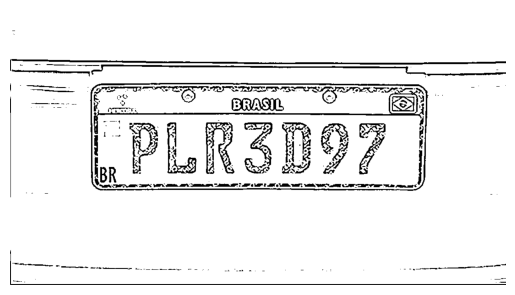

In [17]:
threshold_adaptive = cv2.adaptiveThreshold(image_car_1_GRAY, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 8)
plt.imshow(threshold_adaptive, cmap="gray")
plt.axis("off")
plt.show()

Limiarização de Otsu

In [18]:
threshold_adaptive

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [  0,   0, 255, ..., 255, 255, 255],
       [  0,   0,   0, ...,   0,   0,   0],
       [255,   0,   0, ...,   0,   0,   0]], dtype=uint8)

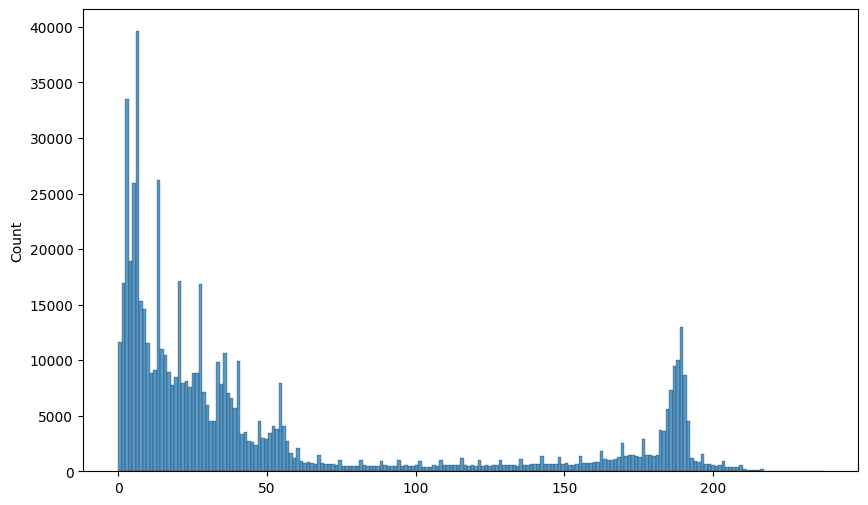

In [19]:
import seaborn as sns
ax = sns.histplot(image_car_1_GRAY.flatten())
ax.figure.set_size_inches(10,6)

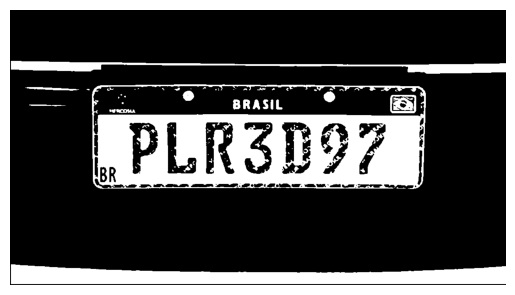

Threshold: 96.0


In [20]:
value, threshold_otsu = cv2.threshold(image_car_1_GRAY, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
plt.imshow(threshold_otsu, cmap="gray")
plt.axis("off")
plt.show()
print(f"Threshold: {value}")

In [21]:
config_tesseract = '--tessdata-dir ../tessdata --psm 6'
text_car = pytesseract.image_to_string(threshold_otsu, lang = 'por', config = config_tesseract)
print(text_car)

, PLRSD97
EDnA



## Aula 03

Transformação morfológicas

kernel = elemento estruturante

erosão e dilatação

In [22]:
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))

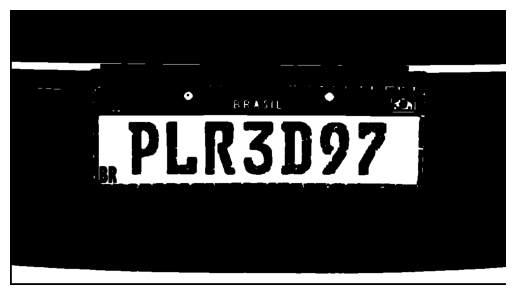

In [23]:
erosion = cv2.erode(threshold_otsu, kernel)
plt.imshow(erosion, cmap="gray")
plt.axis("off")
plt.show()

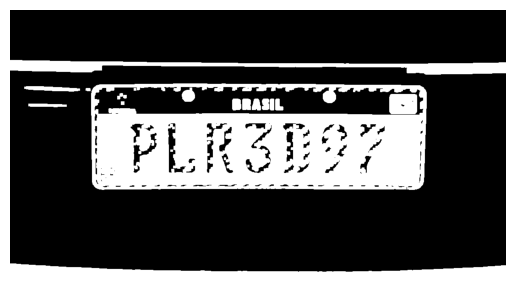

In [24]:
dilation = cv2.dilate(threshold_otsu, kernel)
plt.imshow(dilation, cmap="gray")
plt.axis("off")
plt.show()

Abertura e fechamento

Abertura = erosão seguida de dilatação

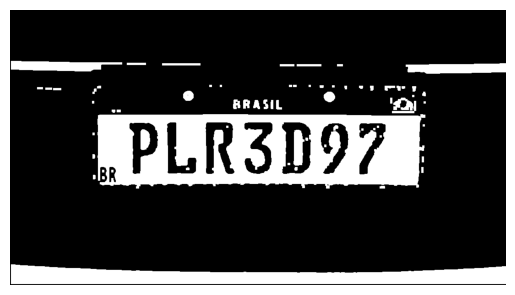

In [25]:
# manualmente
erosion = cv2.erode(threshold_otsu, kernel)
dilation = cv2.dilate(erosion, kernel)
plt.imshow(dilation, cmap="gray")
plt.axis("off")
plt.show()

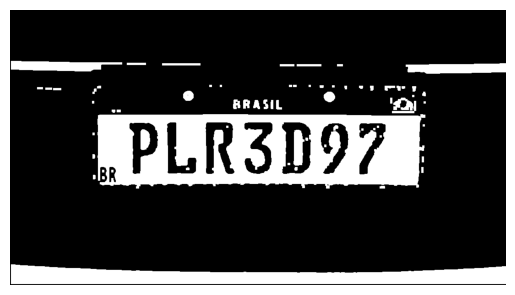

In [26]:
# mas tem função
opening = cv2.morphologyEx(threshold_otsu, cv2.MORPH_OPEN, kernel)
plt.imshow(opening, cmap="gray")
plt.axis("off")
plt.show()

Fechamento = dilatação seguida de erosão

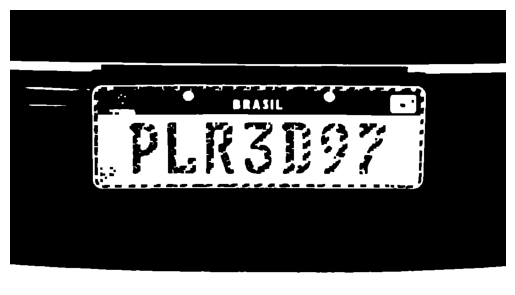

In [27]:
# manualmente
dilation = cv2.dilate(threshold_otsu, kernel)
erosion = cv2.erode(dilation, kernel)
plt.imshow(erosion, cmap="gray")
plt.axis("off")
plt.show()

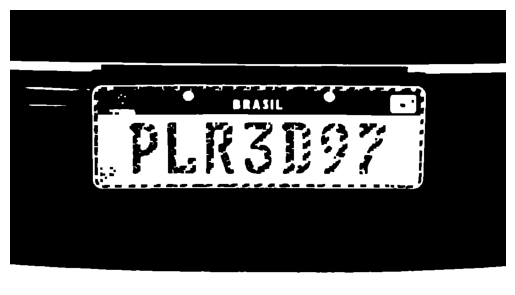

In [28]:
# mas tem função
closing = cv2.morphologyEx(threshold_otsu, cv2.MORPH_CLOSE, kernel)
plt.imshow(closing, cmap="gray")
plt.axis("off")
plt.show()

Outras transformações

- gradientes morfológico = dilatação - erosão
- cartola = imagem original - abertura
- chapéu preto = fechamento - imagem original

Gradiente morfológico

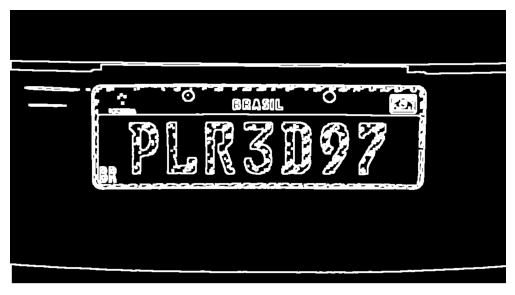

In [29]:
gradient = cv2.morphologyEx(threshold_otsu, cv2.MORPH_GRADIENT, kernel)
plt.imshow(gradient, cmap="gray")
plt.axis("off")
plt.show()

Cartola

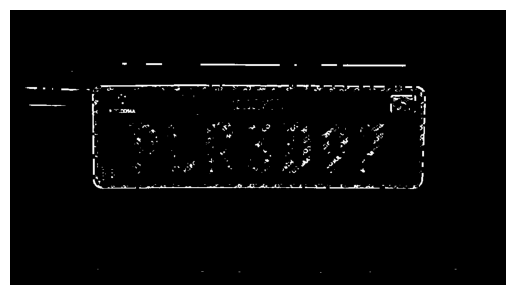

In [30]:
top_hat = cv2.morphologyEx(threshold_otsu, cv2.MORPH_TOPHAT, kernel)
plt.imshow(top_hat, cmap="gray")
plt.axis("off")
plt.show()

In [31]:
kernel_licence_size = cv2.getStructuringElement(cv2.MORPH_RECT, (40, 13))

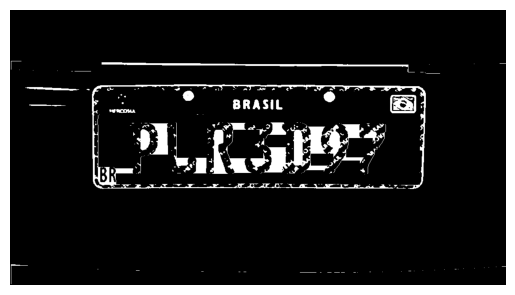

In [32]:
top_hat = cv2.morphologyEx(threshold_otsu, cv2.MORPH_TOPHAT, kernel_licence_size)
plt.imshow(top_hat, cmap="gray")
plt.axis("off")
plt.show()

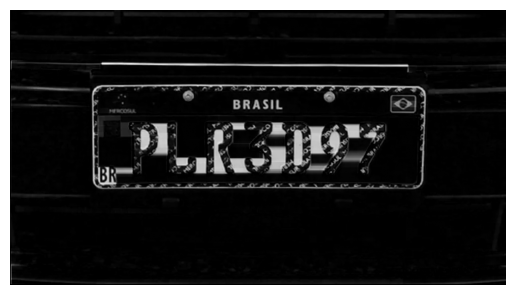

In [33]:
top_hat = cv2.morphologyEx(image_car_1_GRAY, cv2.MORPH_TOPHAT, kernel_licence_size)
plt.imshow(top_hat, cmap="gray")
plt.axis("off")
plt.show()

Chapéu preto

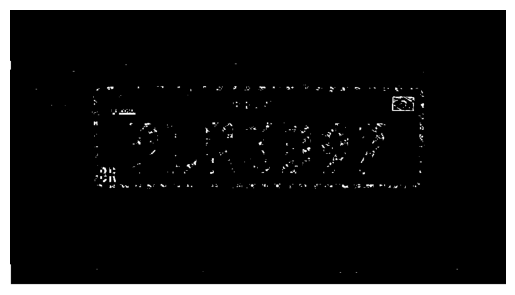

In [34]:
black_hat = cv2.morphologyEx(threshold_otsu, cv2.MORPH_BLACKHAT, kernel)
plt.imshow(black_hat, cmap="gray")
plt.axis("off")
plt.show()

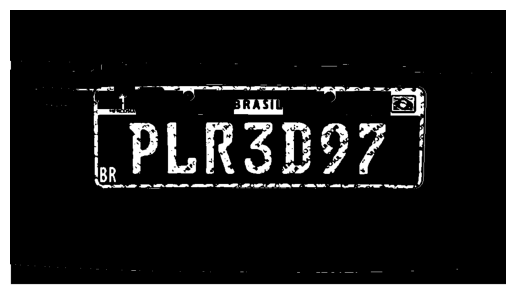

In [35]:
black_hat = cv2.morphologyEx(threshold_otsu, cv2.MORPH_BLACKHAT, kernel_licence_size)
plt.imshow(black_hat, cmap="gray")
plt.axis("off")
plt.show()

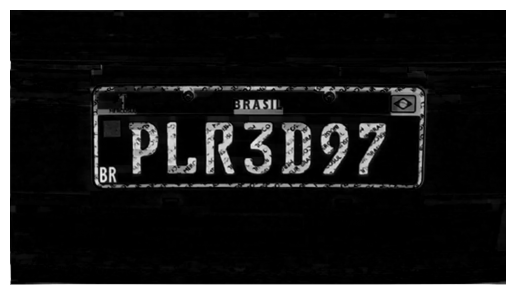

In [36]:
black_hat = cv2.morphologyEx(image_car_1_GRAY, cv2.MORPH_BLACKHAT, kernel_licence_size)
plt.imshow(black_hat, cmap="gray")
plt.axis("off")
plt.show()

Tentando ler algumas das imagens

In [37]:
config_tesseract = '--tessdata-dir ../tessdata --psm 6'
text_car = pytesseract.image_to_string(erosion, lang = 'por', config = config_tesseract)
print(text_car)

—TA
L PLRSCO7
ee o



In [38]:
config_tesseract = '--tessdata-dir ../tessdata --psm 6'
text_car = pytesseract.image_to_string(black_hat, lang = 'por', config = config_tesseract)
print(text_car)

— LPLKSD97



## Aula 04

Extraindo bordas e ver apenas a placa, com a função Canny

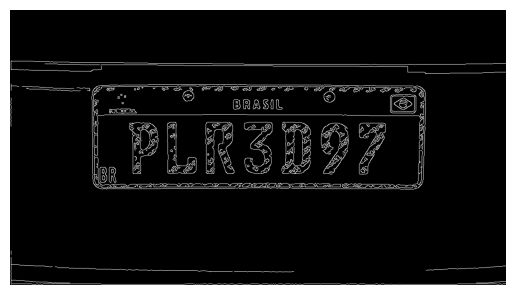

In [39]:
edges = cv2.Canny(image_car_1_GRAY, 100, 200)
plt.imshow(edges, cmap="gray")
plt.axis("off")
plt.show()

In [40]:
outlines, hierarchies = cv2.findContours(edges, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
print(outlines)

(array([[[1069,  593]],

       [[1068,  594]],

       [[1057,  594]],

       [[1056,  595]],

       [[1045,  595]],

       [[1044,  596]],

       [[1018,  596]],

       [[1044,  596]],

       [[1045,  595]],

       [[1056,  595]],

       [[1057,  594]],

       [[1068,  594]],

       [[1069,  593]],

       [[1082,  593]]], dtype=int32), array([[[490, 571]],

       [[489, 572]],

       [[490, 571]],

       [[517, 571]],

       [[518, 572]],

       [[519, 572]],

       [[520, 571]],

       [[548, 571]],

       [[549, 572]],

       [[553, 572]],

       [[554, 571]],

       [[565, 571]],

       [[566, 572]],

       [[568, 572]],

       [[569, 571]],

       [[570, 572]],

       [[572, 572]],

       [[573, 571]],

       [[576, 571]],

       [[577, 572]],

       [[587, 572]],

       [[588, 571]],

       [[590, 571]],

       [[591, 572]],

       [[601, 572]],

       [[602, 571]],

       [[603, 571]],

       [[604, 572]],

       [[614, 572]],

       [[61

Aproximação do contorno para um políguno

In [41]:
for outline in outlines:
    epsilon = 0.02 * cv2.arcLength(outline, True)
    approximation = cv2.approxPolyDP(outline, epsilon, True)
    if cv2.isContourConvex(approximation) and len(approximation) == 4:
        position = approximation
        break

In [42]:
position

array([[[180, 178]],

       [[196, 391]],

       [[901, 375]],

       [[894, 168]]], dtype=int32)

- ponto inicial
- comprimento
- altura

In [43]:
x, y, w, h = cv2.boundingRect(position)

In [44]:
print(f"x = {x}")
print(f"y = {y}")
print(f"w = {w}")
print(f"h = {h}")

x = 180
y = 168
w = 722
h = 224


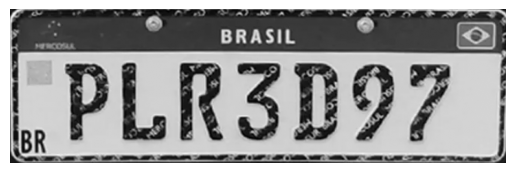

In [45]:
license_plate = image_car_1_GRAY[y:y+h, x:x+w]
plt.imshow(license_plate, cmap="gray")
plt.axis("off")
plt.show()

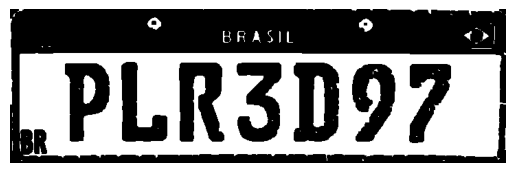

In [46]:
value, threshold_otsu = cv2.threshold(license_plate, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
erosion_plate = cv2.erode(threshold_otsu, cv2.getStructuringElement(cv2.MORPH_RECT, (4, 4)))
plt.imshow(erosion_plate, cmap="gray")
plt.axis("off")
plt.show()

In [47]:
config_tesseract = '--tessdata-dir ../tessdata --psm 6'
text_car = pytesseract.image_to_string(erosion_plate, lang = 'por', config = config_tesseract)
print(text_car)

In [48]:
# print(text_car.group(0))

como a do instrutor deu "L PLR3D97"

In [49]:
import re
text_extract = re.search('\w{3}\d{1}\w{1}\d{2}', text_car)
text_extract

Aplicação para outro cenário

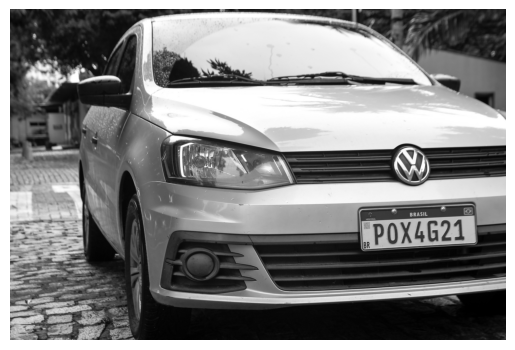

In [50]:
image_car_2 = cv2.imread("images/placa_carro2.jpg")
image_car_2_GRAY = cv2.cvtColor(image_car_2, cv2.COLOR_BGR2GRAY)
plt.imshow(image_car_2_GRAY, cmap="gray")
plt.axis("off")
plt.show()

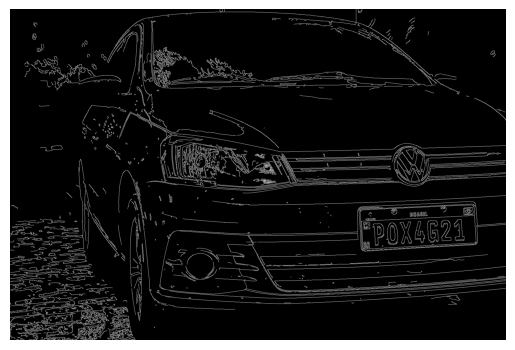

In [51]:
edges = cv2.Canny(image_car_2_GRAY, 100, 200)
plt.imshow(edges, cmap="gray")
plt.axis("off")
plt.show()

In [52]:
outlines, hierarchies = cv2.findContours(edges, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
outlines = sorted(outlines, key=cv2.contourArea, reverse=True)[:10]

for outline in outlines:
    epsilon = 0.02 * cv2.arcLength(outline, True)
    approximation = cv2.approxPolyDP(outline, epsilon, True)
    if cv2.isContourConvex(approximation) and len(approximation) == 4:
        position = approximation
        break

x, y, w, h = cv2.boundingRect(position)

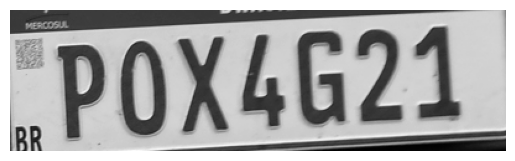

In [53]:
license_plate = image_car_2_GRAY[y:y+h, x:x+w]
plt.imshow(license_plate, cmap="gray")
plt.axis("off")
plt.show()

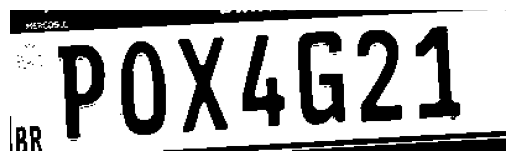

In [54]:
value, threshold_otsu = cv2.threshold(license_plate, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
plt.imshow(threshold_otsu, cmap="gray")
plt.axis("off")
plt.show()

In [55]:
config_tesseract = '--tessdata-dir ../tessdata --psm 6'
text_car = pytesseract.image_to_string(threshold_otsu, lang = 'por', config = config_tesseract)
print(text_car)

“POX4G21



In [56]:
import re
text_extract = re.search('\w{3}\d{1}\w{1}\d{2}', text_car)
text_extract

<re.Match object; span=(1, 8), match='POX4G21'>

In [57]:
print(text_extract.group(0))

POX4G21


## Aula 05

nova abordagem para identificar localização da placa

black hat = ja que destaca item escuro em fundo branco

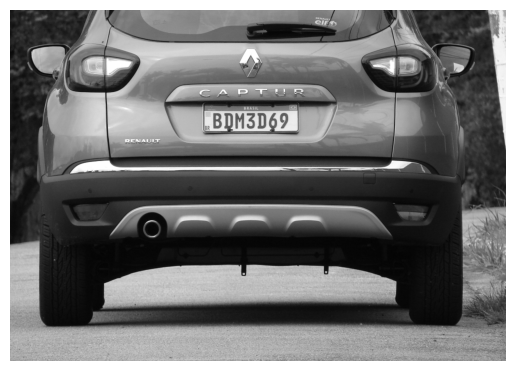

In [58]:
image_car_3 = cv2.imread("images/placa_carro3.jpg")
image_car_3_GRAY = cv2.cvtColor(image_car_3, cv2.COLOR_BGR2GRAY)
plt.imshow(image_car_3_GRAY, cmap="gray")
plt.axis("off")
plt.show()

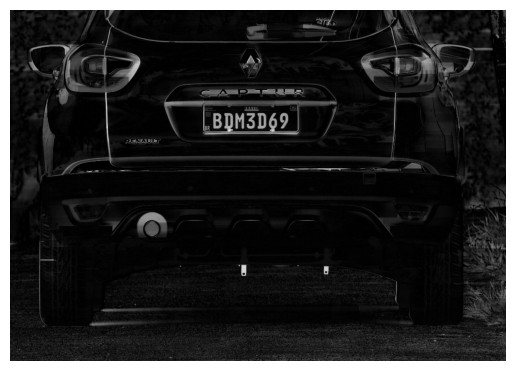

In [59]:
kernel_rectangular = cv2.getStructuringElement(cv2.MORPH_RECT, (40, 13))
black_hat = cv2.morphologyEx(image_car_3_GRAY, cv2.MORPH_BLACKHAT, kernel_rectangular)
plt.imshow(black_hat, cmap="gray")
plt.axis("off")
plt.show()

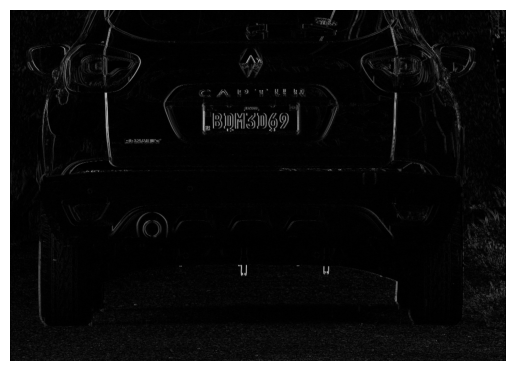

In [60]:
import numpy as np

sobel_x = cv2.Sobel(black_hat, ddepth=cv2.CV_32F, dx=1, dy=0, ksize=1)
sobel_x = np.absolute(sobel_x)
sobel_x = sobel_x.astype('uint8')

plt.imshow(sobel_x, cmap="gray")
plt.axis("off")
plt.show()

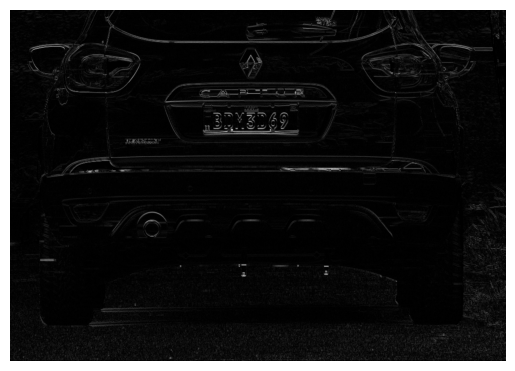

In [61]:
# desafio, como fica no eixo y?

sobel_y = cv2.Sobel(black_hat, ddepth=cv2.CV_32F, dx=0, dy=1, ksize=1)
sobel_y = np.absolute(sobel_y)
sobel_y = sobel_y.astype('uint8')

plt.imshow(sobel_y, cmap="gray")
plt.axis("off")
plt.show()

GaussianBlur para remover ruidos, seguido da operação de fechamento

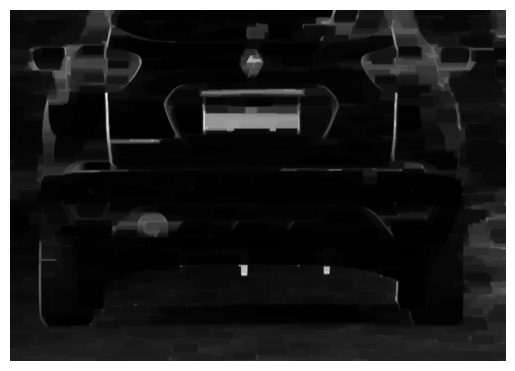

In [62]:
sobel_x = cv2.GaussianBlur(sobel_x, (5, 5), 0)
sobel_x = cv2.morphologyEx(sobel_x, cv2.MORPH_CLOSE, kernel_rectangular)

plt.imshow(sobel_x, cmap="gray")
plt.axis("off")
plt.show()

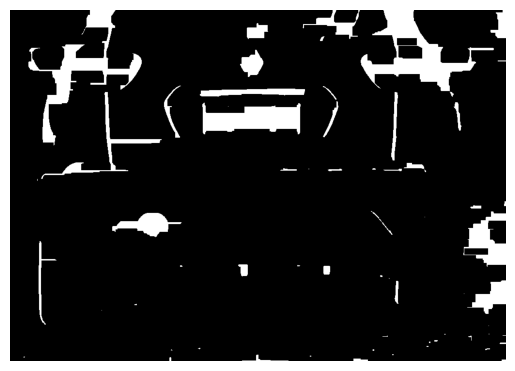

In [63]:
value, threshold_otsu = cv2.threshold(sobel_x, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
plt.imshow(threshold_otsu, cmap="gray")
plt.axis("off")
plt.show()

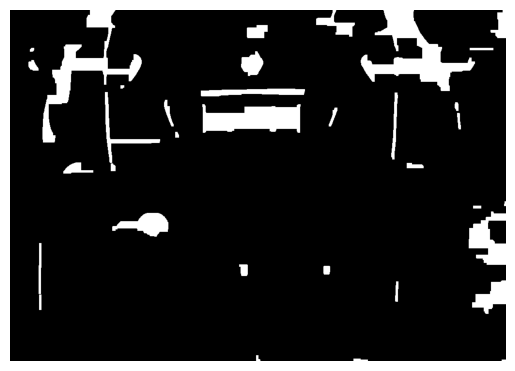

In [64]:
kernel_square = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
erosion = cv2.erode(threshold_otsu, kernel_square, iterations=2)
dilation = cv2.dilate(erosion, kernel_square, iterations=2)
plt.imshow(dilation, cmap="gray")
plt.axis("off")
plt.show()

Efeito de mascara

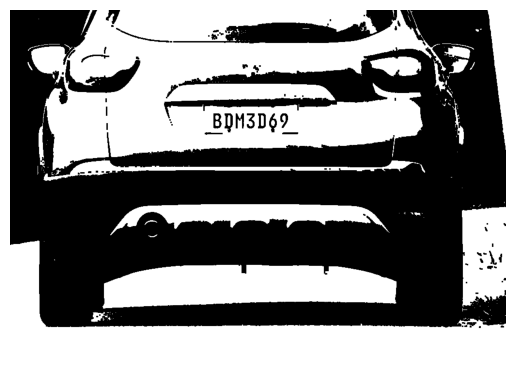

In [65]:
closing = cv2.morphologyEx(image_car_3_GRAY, cv2.MORPH_CLOSE, kernel_square)
value, mask = cv2.threshold(closing, 0, 255, cv2.THRESH_BINARY |cv2.THRESH_OTSU)
plt.imshow(mask, cmap="gray")
plt.axis("off")
plt.show()

Função Bitwise and

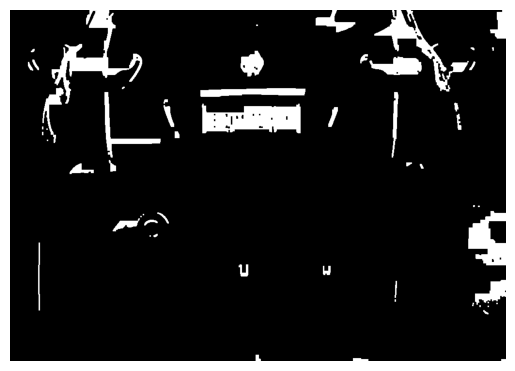

In [66]:
threshold_bitwise = cv2.bitwise_and(dilation, dilation, mask=mask)
dilation = cv2.dilate(threshold_bitwise, kernel_square, iterations=2)
erosion = cv2.erode(dilation, kernel_square, iterations=1)

plt.imshow(erosion, cmap="gray")
plt.axis("off")
plt.show()

Função clear border

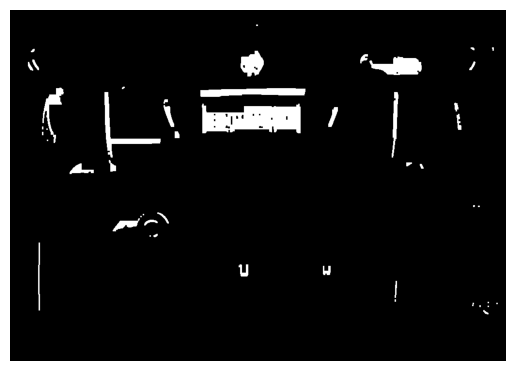

In [68]:
from skimage.segmentation import clear_border
thresholding = clear_border(erosion)
plt.imshow(thresholding, cmap="gray")
plt.axis("off")
plt.show()

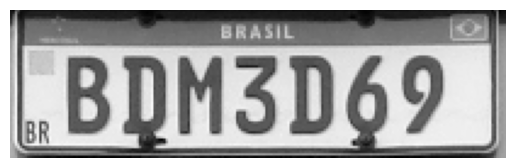

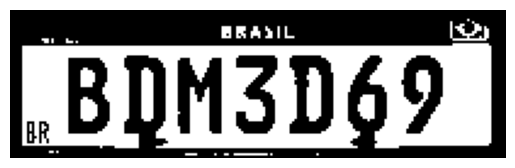

In [72]:
outlines, hierarchies = cv2.findContours(thresholding, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
outlines = sorted(outlines, key=cv2.contourArea, reverse=True)[:10]

for outline in outlines:
    x, y, w, h = cv2.boundingRect(outline)
    proportion = float(w)/h
    if proportion >=3 and proportion <=3.5:
        license_plate = image_car_3_GRAY[y:y+h, x:x+w]
        value, interest_region = cv2.threshold(license_plate, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
        interest_region = clear_border(interest_region)
        plt.imshow(license_plate, cmap="gray")
        plt.axis("off")
        plt.show()
        plt.imshow(interest_region, cmap="gray")
        plt.axis("off")
        plt.show()

In [73]:
config_tesseract = '--tessdata-dir ../tessdata --psm 6'
text_car = pytesseract.image_to_string(interest_region, lang='por', config=config_tesseract)
print(text_car)

.BDM3D69



In [74]:
text_extract = re.search('\w{3}\d{1}\w{1}\d{2}', text_car)
text_extract

<re.Match object; span=(1, 8), match='BDM3D69'>

In [76]:
print(text_extract.group(0))

BDM3D69
